## 1. Load Dataset

In [143]:
import pandas as pd

dataset = pd.read_csv('data/german_credit_data.csv')

dataset.head(5)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [144]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [145]:
for col in dataset.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(dataset[col].value_counts(dropna=False))


Sex
Sex
male      690
female    310
Name: count, dtype: int64

Housing
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

Saving accounts
Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Checking account
Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Risk
Risk
good    700
bad     300
Name: count, dtype: int64


In [146]:
dataset['Saving accounts'] = dataset['Saving accounts'].fillna('unknown')
dataset['Checking account'] = dataset['Checking account'].fillna('unknown')

In [147]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   1000 non-null   object
 6   Checking account  1000 non-null   object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [148]:
for col in dataset.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(dataset[col].value_counts(dropna=False))


Sex
Sex
male      690
female    310
Name: count, dtype: int64

Housing
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

Saving accounts
Saving accounts
little        603
unknown       183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Checking account
Checking account
unknown     394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Risk
Risk
good    700
bad     300
Name: count, dtype: int64


## 2. Split Feature and Target

In [149]:
x = dataset.drop(columns=['Risk', 'Unnamed: 0'])
y = dataset['Risk']

print("Feature")
x.info()
print('\n')
print("Target")
y.info()

Feature
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   1000 non-null   object
 5   Checking account  1000 non-null   object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


Target
<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Risk
Non-Null Count  Dtype 
--------------  ----- 
1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


## 3. Encoding Categorical Column

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [151]:
categorical_cols = x.select_dtypes(include='object').columns
numeric_cols = x.select_dtypes(exclude='object').columns


print("Categorical columns:")
print(list(categorical_cols))

print("\nNumerical columns:")
print(list(numeric_cols))

Categorical columns:
['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

Numerical columns:
['Age', 'Job', 'Credit amount', 'Duration']


In [152]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

## 4. Split Dataset

In [153]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 5. Random Forest

In [154]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('random_forest', rf_model)
    ]
)

# training
model.fit(x_train, y_train)

# prediksi
y_pred = model.predict(x_test)

In [155]:
# Evaluasi

# Prediction
y_pred_rf = model.predict(x_test)

# Probability untuk kelas "bad"
bad_index = list(model.classes_).index('bad')

y_prob_rf = model.predict_proba(x_test)[:, bad_index]

# Ubah target menjadi binary
y_pred_binary_rf = (y_pred_rf == 'bad').astype(int)

# Metrics
precision_rf = precision_score(
    y_test_binary,
    y_pred_binary_rf
)

recall_rf = recall_score(
    y_test_binary,
    y_pred_binary_rf
)

f1_rf = f1_score(
    y_test_binary,
    y_pred_binary_rf
)

roc_auc_rf = roc_auc_score(
    y_test_binary,
    y_prob_rf
)

print("=== Random Forest Result ===")
print(f"Precision : {precision_rf:.3f}")
print(f"Recall    : {recall_rf:.3f}")
print(f"F1-score  : {f1_rf:.3f}")
print(f"ROC-AUC   : {roc_auc_rf:.3f}")

=== Random Forest Result ===
Precision : 0.566
Recall    : 0.500
F1-score  : 0.531
ROC-AUC   : 0.767


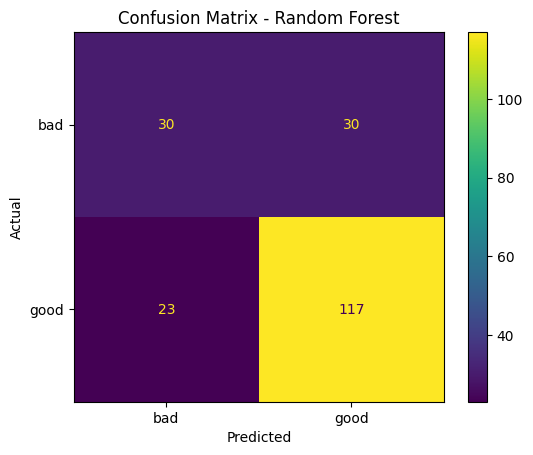

In [156]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

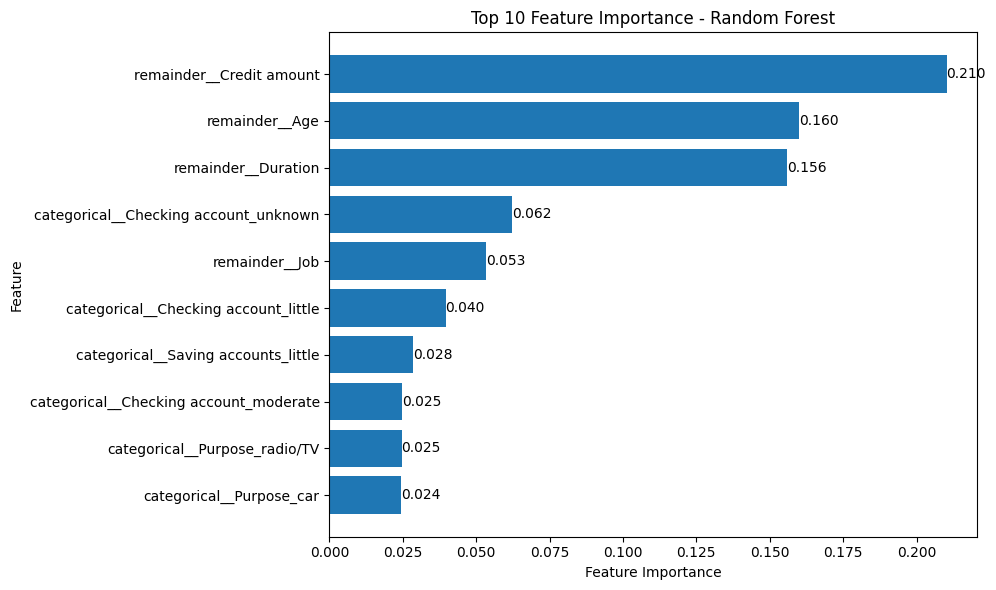

In [157]:
# Top 10 Feature Importance

top_10 = feature_importance.head(10).sort_values(
    by='Importance'
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10['Feature'],
    top_10['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - Random Forest')

for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.3f}',
        va='center'
    )

plt.tight_layout()
plt.show()

## 6. Logistic Regression

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [159]:
# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('logistic_regression', logistic_model)
    ]
)


# Training

model.fit(x_train, y_train)


# Prediction

y_pred = model.predict(x_test)

D:\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [160]:
# Evaluation

# Prediction
y_pred_log = model.predict(x_test)

# Probability untuk kelas "bad"
bad_index = list(model.classes_).index('bad')

y_prob_log = model.predict_proba(x_test)[:, bad_index]

# Ubah target menjadi binary
y_test_binary = (y_test == 'bad').astype(int)
y_pred_binary_log = (y_pred_log == 'bad').astype(int)

# Metrics
precision_log = precision_score(
    y_test_binary,
    y_pred_binary_log
)

recall_log = recall_score(
    y_test_binary,
    y_pred_binary_log
)

f1_log = f1_score(
    y_test_binary,
    y_pred_binary_log
)

roc_auc_log = roc_auc_score(
    y_test_binary,
    y_prob_log
)

print("=== Logistic Regression Result ===")
print(f"Precision : {precision_log:.3f}")
print(f"Recall    : {recall_log:.3f}")
print(f"F1-score  : {f1_log:.3f}")
print(f"ROC-AUC   : {roc_auc_log:.3f}")

=== Logistic Regression Result ===
Precision : 0.587
Recall    : 0.450
F1-score  : 0.509
ROC-AUC   : 0.749


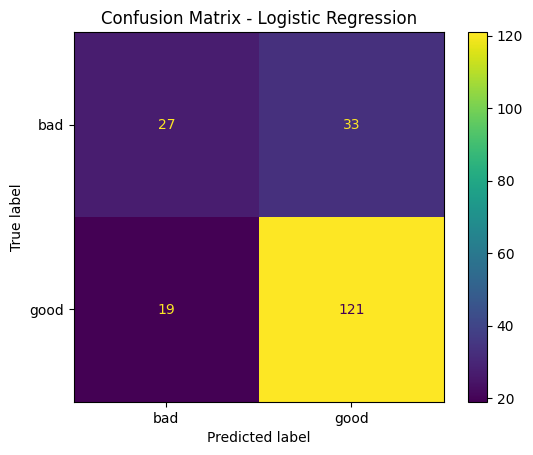

In [161]:
# Visualisasi Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 7. Result Comparison

In [163]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Precision': [
        0.587,
        0.566
    ],
    'Recall': [
        0.450,
        0.500
    ],
    'F1-score': [
        0.509,
        0.531
    ],
    'ROC-AUC': [
        0.749,
        0.767
    ]
})

print(results)

                 Model  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression      0.587    0.45     0.509    0.749
1        Random Forest      0.566    0.50     0.531    0.767
